# 03 — LoRA Fine-Tuning: Scenario-Adaptive Beam Prediction

**Project:** LWM-LoRA: Scenario-Adaptive mmWave Beam Prediction via LoRA-Tuned Foundation Models for 6G Networks  
**Author:** Nabeegh Khan | MEng ECE Candidate, University of Toronto  
**Portfolio:** [github.com/nabeegh-khan/6g-lwm-beam-prediction](https://github.com/nabeegh-khan/6g-lwm-beam-prediction)

---

## What this notebook does

1. Applies **LoRA (Low-Rank Adaptation)** to LWM's Transformer encoder via HuggingFace PEFT
2. Jointly fine-tunes LoRA adapters + MLP head for beam prediction — LWM encoder is no longer frozen
3. Runs a **LoRA rank ablation**: r ∈ {2, 4, 8, 16} to find the optimal adapter size
4. Compares four conditions per scenario: Frozen LWM | Full fine-tune | LoRA r=4 | LoRA r=8
5. Tests **cross-scenario transfer**: train on Miami, adapt to Santaclara with LoRA using only 20% target data
6. Logs all experiments to **W&B** with a hyperparameter sweep table

## The core research question
*Can LoRA adapters (< 2% extra parameters) match or exceed full fine-tuning accuracy
while enabling cheap per-scenario adaptation?*

In [1]:
%pip install -q peft wandb transformers --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.3 MB/s eta 0:00:00


## Section 1 — Environment Setup

In [2]:
import os, sys, random, subprocess, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset, random_split
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

import peft
print(f"PyTorch: {torch.__version__}")
print(f"PEFT:    {peft.__version__}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128
PEFT:    0.19.1


## Section 2 — Mount Drive, Restore Paths & W&B

In [3]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/6g-lwm-beam-prediction")
PROC_DIR   = DRIVE_ROOT / "data" / "processed"
EMB_DIR    = DRIVE_ROOT / "data" / "embeddings"
CKPT_DIR   = DRIVE_ROOT / "checkpoints"
FIG_DIR    = DRIVE_ROOT / "figures"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# verify files from previous notebooks
print("Checking required files:")
required = [
    PROC_DIR / "city_6_miami.pt",
    PROC_DIR / "city_11_santaclara.pt",
    PROC_DIR / "city_12_fortworth.pt",
    EMB_DIR  / "city_6_miami_cls_emb.pt",
    EMB_DIR  / "city_11_santaclara_cls_emb.pt",
    EMB_DIR  / "city_12_fortworth_cls_emb.pt",
]
for p in required:
    status = "OK" if p.exists() else "MISSING"
    print(f"  {status} → {p.name}")

import wandb
wandb.login()

run = wandb.init(
    project="6g-lwm-beam-prediction",
    name="03_lora_finetuning",
    tags=["lora", "peft", "finetuning", "ablation"],
    config={
        "seed":        SEED,
        "n_beams":     64,
        "lora_ranks":  [2, 4, 8, 16],
        "epochs":      30,
        "lr":          1e-3,
        "batch_size":  128,
        "lora_alpha":  32,
        "lora_dropout": 0.1,
        "target_modules": ["proj"],
    },
    notes="LoRA rank ablation + cross-scenario transfer experiment"
)
print(f"\nW&B run: {run.name}")
print(f"W&B URL: {run.url}")

Mounted at /content/drive
Checking required files:
  OK → city_6_miami.pt
  OK → city_11_santaclara.pt
  OK → city_12_fortworth.pt
  OK → city_6_miami_cls_emb.pt
  OK → city_11_santaclara_cls_emb.pt
  OK → city_12_fortworth_cls_emb.pt


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nabeegh-khan (nabeegh-khan-university-of-toronto) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



W&B run: 03_lora_finetuning
W&B URL: https://wandb.ai/nabeegh-khan-university-of-toronto/6g-lwm-beam-prediction/runs/hjcgom0t


## Section 3 — Clone LWM & Load Model

In [4]:
LWM_DIR = "/content/LWM"

if not os.path.exists(LWM_DIR):
    print("Cloning wi-lab/lwm-v1.1...")
    result = subprocess.run(
        ["git", "clone", "https://huggingface.co/wi-lab/lwm-v1.1", LWM_DIR],
        capture_output=True, text=True
    )
    print("Done." if result.returncode == 0 else f"ERROR: {result.stderr}")
else:
    print("LWM repo already present.")

if LWM_DIR not in sys.path:
    sys.path.insert(0, LWM_DIR)

from lwm_model import lwm as LWMModel

def load_lwm(device="cuda"):
    """Load a fresh copy of pre-trained LWM weights."""
    model      = LWMModel().to(device)
    state_dict = torch.load(f"{LWM_DIR}/models/model.pth", map_location=device)
    clean_sd   = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(clean_sd)
    return model

# verify it loads cleanly
test_model = load_lwm(device)
n_params   = sum(p.numel() for p in test_model.parameters())
print(f"LWM loaded — {n_params:,} parameters")
del test_model
torch.cuda.empty_cache()

Cloning wi-lab/lwm-v1.1...
Done.
LWM loaded — 2,470,304 parameters


## Section 4 — Load Scenario Data

In [5]:
SCENARIOS = ["city_6_miami", "city_11_santaclara", "city_12_fortworth"]
N_BEAMS   = 64

scenario_data = {}
for sc_name in SCENARIOS:
    saved = torch.load(str(PROC_DIR / f"{sc_name}.pt"), map_location="cpu")
    scenario_data[sc_name] = {
        "patches": saved["patches"].float(),
        "labels":  saved["labels"].long(),
    }
    print(f"{sc_name}: patches={saved['patches'].shape}, "
          f"labels={saved['labels'].shape}")


def make_loaders(patches, labels, train_ratio=0.8, batch_size=128, seed=42):
    dataset   = TensorDataset(patches, labels)
    n_train   = int(train_ratio * len(dataset))
    n_val     = len(dataset) - n_train
    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                    generator=generator)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


print("\nData loaded.")

city_6_miami: patches=torch.Size([10441, 33, 32]), labels=torch.Size([10441])
city_11_santaclara: patches=torch.Size([1104, 65, 32]), labels=torch.Size([1104])
city_12_fortworth: patches=torch.Size([1113, 129, 32]), labels=torch.Size([1113])

Data loaded.


## Section 5 — Inspect LWM Layers & Define LoRA Wrapper

LWM is a custom PyTorch Transformer — not a HuggingFace AutoModel — so PEFT's
`get_peft_model` requires knowing the exact names of the linear layers to target.

We inspect all named modules to identify the attention projection layers,
then inject low-rank adapters at those positions.

In [6]:
# inspect all named linear layers in LWM so we know what to target
temp_model = load_lwm(device)

print("All nn.Linear layers in LWM:")
print(f"{'Name':<45} {'Shape'}")
print("-" * 65)
linear_names = []
for name, module in temp_model.named_modules():
    if isinstance(module, nn.Linear):
        linear_names.append(name)
        print(f"  {name:<45} {list(module.weight.shape)}")

del temp_model
torch.cuda.empty_cache()
print(f"\nTotal linear layers: {len(linear_names)}")

All nn.Linear layers in LWM:
Name                                          Shape
-----------------------------------------------------------------
  embedding.proj                                [128, 32]
  layers.0.enc_self_attn.W_Q                    [128, 128]
  layers.0.enc_self_attn.W_K                    [128, 128]
  layers.0.enc_self_attn.W_V                    [128, 128]
  layers.0.enc_self_attn.linear                 [128, 128]
  layers.0.pos_ffn.fc1                          [512, 128]
  layers.0.pos_ffn.fc2                          [128, 512]
  layers.1.enc_self_attn.W_Q                    [128, 128]
  layers.1.enc_self_attn.W_K                    [128, 128]
  layers.1.enc_self_attn.W_V                    [128, 128]
  layers.1.enc_self_attn.linear                 [128, 128]
  layers.1.pos_ffn.fc1                          [512, 128]
  layers.1.pos_ffn.fc2                          [128, 512]
  layers.2.enc_self_attn.W_Q                    [128, 128]
  layers.2.enc_self_attn.W_K

## Section 6 — LoRA Implementation

LWM uses custom PyTorch modules rather than HuggingFace AutoModel classes,
so we implement LoRA injection directly. A `LoRALinear` wrapper replaces
each target linear layer: the original weights are frozen and two low-rank
matrices A ∈ ℝ^(r×d_in) and B ∈ ℝ^(d_out×r) are trained instead.

The forward pass becomes: y = W₀x + (BA)x × (α/r)

We target the four attention projection layers per Transformer block:
W_Q, W_K, W_V, and the output projection (linear).

In [7]:
class LoRALinear(nn.Module):
    """
    Wraps an existing nn.Linear with a low-rank LoRA adapter.

    The original weight matrix W0 is frozen.
    We train two small matrices: A (r x d_in) and B (d_out x r).
    Forward: y = W0(x) + (B @ A)(x) * scaling

    scaling = lora_alpha / r  — controls how much the adapter contributes
    """
    def __init__(self, original: nn.Linear, r: int,
                 lora_alpha: int = 32, lora_dropout: float = 0.1):
        super().__init__()
        self.original  = original
        d_in           = original.in_features
        d_out          = original.out_features
        self.scaling   = lora_alpha / r
        self.dropout   = nn.Dropout(lora_dropout)

        # LoRA matrices — these are the only trainable parameters
        self.lora_A = nn.Linear(d_in, r, bias=False)
        self.lora_B = nn.Linear(r, d_out, bias=False)

        # standard LoRA init: A ~ N(0,1), B = 0
        # B=0 means the adapter starts as an identity — no disruption at step 0
        nn.init.kaiming_uniform_(self.lora_A.weight, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

        # freeze original weights
        for p in self.original.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.original(x) + self.scaling * self.lora_B(
            self.lora_A(self.dropout(x))
        )


def inject_lora(model: nn.Module,
                target_suffixes: list,
                r: int,
                lora_alpha: int = 32,
                lora_dropout: float = 0.1) -> nn.Module:
    """
    Replaces all nn.Linear layers whose name ends with one of target_suffixes
    with a LoRALinear wrapper. All other layers remain frozen.

    Returns the modified model.
    """
    # first freeze everything
    for p in model.parameters():
        p.requires_grad = False

    replaced = 0
    for name, module in list(model.named_modules()):
        # get the leaf name (after the last dot)
        leaf = name.split(".")[-1]
        if not isinstance(module, nn.Linear):
            continue
        if leaf not in target_suffixes:
            continue

        # navigate to parent module and replace the child
        parts  = name.split(".")
        parent = model
        for part in parts[:-1]:
            parent = getattr(parent, part)

        lora_layer = LoRALinear(module, r=r,
                                lora_alpha=lora_alpha,
                                lora_dropout=lora_dropout)
        setattr(parent, parts[-1], lora_layer)
        replaced += 1

    return model, replaced


def count_trainable(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# --- quick test: inject LoRA r=4 on a fresh LWM and count params ---
test_model = load_lwm(device)
TARGET_LAYERS = ["W_Q", "W_K", "W_V", "linear"]

test_model, n_replaced = inject_lora(
    test_model, target_suffixes=TARGET_LAYERS,
    r=4, lora_alpha=32, lora_dropout=0.1
)
total, trainable = count_trainable(test_model)
print(f"Layers replaced with LoRA: {n_replaced}")
print(f"Total parameters:          {total:,}")
print(f"Trainable (LoRA only):     {trainable:,}")
print(f"Trainable %:               {100*trainable/total:.2f}%")
del test_model
torch.cuda.empty_cache()

Layers replaced with LoRA: 49
Total parameters:          2,520,480
Trainable (LoRA only):     50,176
Trainable %:               1.99%


## Section 7 — LWM + LoRA + MLP Head: Combined Model

We wrap LWM (with injected LoRA adapters) and the MLP prediction head
into a single end-to-end model. During training, gradients flow through
the MLP head and the LoRA adapter matrices only — the original LWM
weights remain completely frozen.

In [8]:
class BeamMLP(nn.Module):
    """MLP head for beam prediction — same architecture as Notebook 02."""
    def __init__(self, input_dim=128, hidden_dim=256, n_beams=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_beams),
        )
    def forward(self, x):
        return self.net(x)


class LWMLoRA(nn.Module):
    """
    End-to-end model: LWM encoder (with LoRA adapters) + MLP beam head.

    Forward pass:
        1. LWM encoder processes tokenized patches → (batch, seq_len, 128)
        2. CLS token (position 0) extracted → (batch, 128)
        3. MLP head maps embedding → (batch, n_beams) logits
    """
    def __init__(self, lwm_encoder, n_beams=64):
        super().__init__()
        self.encoder = lwm_encoder
        self.head    = BeamMLP(input_dim=128, hidden_dim=256,
                               n_beams=n_beams, dropout=0.3)

    def forward(self, patches):
        enc_out  = self.encoder(patches)   # (batch, seq_len, 128)
        cls_emb  = enc_out[0][:, 0, :]    # (batch, 128)
        return self.head(cls_emb)


def build_lwm_lora(r: int, device: str,
                   lora_alpha: int = 32,
                   lora_dropout: float = 0.1,
                   n_beams: int = 64) -> LWMLoRA:
    """
    Builds a fresh LWMLoRA model with LoRA rank r.
    Loads pre-trained weights, injects LoRA, attaches MLP head.
    """
    encoder = load_lwm(device)
    encoder, _ = inject_lora(
        encoder,
        target_suffixes=["W_Q", "W_K", "W_V", "linear"],
        r=r, lora_alpha=lora_alpha, lora_dropout=lora_dropout
    )
    model = LWMLoRA(encoder, n_beams=n_beams).to(device)
    return model


def train_lora(model, train_loader, val_loader,
               epochs=30, lr=1e-3, device="cuda",
               wandb_prefix=""):
    """Training loop — only LoRA adapter + MLP head params are updated."""
    # only pass trainable parameters to the optimizer
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    # MLP head params are trainable by default
    for p in model.head.parameters():
        p.requires_grad = True
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.Adam(trainable_params, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_top1 = 0.0
    history   = {"train_loss": [], "val_top1": [], "val_top3": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        avg_loss = total_loss / len(train_loader)

        model.eval()
        correct_top1 = correct_top3 = total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                top3   = torch.topk(logits, k=3, dim=1).indices
                correct_top1 += (top3[:, 0] == y_batch).sum().item()
                correct_top3 += (top3 == y_batch.unsqueeze(1)).any(dim=1).sum().item()
                total        += len(y_batch)

        top1 = correct_top1 / total
        top3 = correct_top3 / total
        best_top1 = max(best_top1, top1)

        history["train_loss"].append(avg_loss)
        history["val_top1"].append(top1)
        history["val_top3"].append(top3)

        if wandb_prefix:
            wandb.log({
                f"{wandb_prefix}/train_loss": avg_loss,
                f"{wandb_prefix}/val_top1":   top1,
                f"{wandb_prefix}/val_top3":   top3,
                f"{wandb_prefix}/epoch":      epoch,
            })

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | "
                  f"loss={avg_loss:.4f} | top1={top1:.3f} | top3={top3:.3f}")

    return best_top1, history


print("LWMLoRA model and training utilities defined.")

LWMLoRA model and training utilities defined.


## Section 8 — LoRA Rank Ablation

Train LWMLoRA with r ∈ {2, 4, 8, 16} on all three scenarios.
Each rank adds a different number of trainable parameters:
- r=2:  ~12K params (0.5%)
- r=4:  ~25K params (1.0%)
- r=8:  ~50K params (2.0%)
- r=16: ~100K params (4.0%)

In [9]:
LORA_RANKS = [2, 4, 8, 16]
EPOCHS     = 30
LR         = 1e-3
BATCH      = 128

# results[scenario][rank] = best_top1
ablation_results = {sc: {} for sc in SCENARIOS}

for sc_name in SCENARIOS:
    print(f"\n{'='*55}")
    print(f"Scenario: {sc_name}")
    print(f"{'='*55}")
    patches = scenario_data[sc_name]["patches"]
    labels  = scenario_data[sc_name]["labels"]
    train_loader, val_loader = make_loaders(
        patches, labels, train_ratio=0.8, batch_size=BATCH, seed=SEED
    )

    for r in LORA_RANKS:
        print(f"\n  LoRA r={r}")
        model = build_lwm_lora(r=r, device=device)
        total, trainable = count_trainable(model)
        print(f"  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

        best_top1, _ = train_lora(
            model, train_loader, val_loader,
            epochs=EPOCHS, lr=LR, device=device,
            wandb_prefix=f"{sc_name}/lora_r{r}"
        )
        ablation_results[sc_name][r] = best_top1

        # save checkpoint
        ckpt_path = CKPT_DIR / f"lwm_lora_r{r}_{sc_name}.pt"
        torch.save({
            "model_state": model.state_dict(),
            "r": r, "sc_name": sc_name, "top1": best_top1
        }, str(ckpt_path))
        print(f"  Best top-1: {best_top1:.3f} → saved {ckpt_path.name}")

        del model
        torch.cuda.empty_cache()

print(f"\n{'='*55}")
print("LORA RANK ABLATION RESULTS")
print(f"{'='*55}")
header = f"{'Scenario':<25}" + "".join([f"  r={r:>2}" for r in LORA_RANKS])
print(header)
print("-" * 55)
for sc in SCENARIOS:
    row = f"{sc:<25}" + "".join(
        [f"  {ablation_results[sc][r]:.3f}" for r in LORA_RANKS]
    )
    print(row)


Scenario: city_6_miami

  LoRA r=2
  Trainable: 100,032 / 2,570,336 (3.89%)
  Epoch  10/30 | loss=1.0738 | top1=0.669 | top3=0.936
  Epoch  20/30 | loss=0.8682 | top1=0.726 | top3=0.955
  Epoch  30/30 | loss=0.8028 | top1=0.754 | top3=0.958
  Best top-1: 0.756 → saved lwm_lora_r2_city_6_miami.pt

  LoRA r=4
  Trainable: 125,120 / 2,595,424 (4.82%)
  Epoch  10/30 | loss=1.0637 | top1=0.685 | top3=0.944
  Epoch  20/30 | loss=0.8155 | top1=0.737 | top3=0.960
  Epoch  30/30 | loss=0.7391 | top1=0.766 | top3=0.966
  Best top-1: 0.768 → saved lwm_lora_r4_city_6_miami.pt

  LoRA r=8
  Trainable: 175,296 / 2,645,600 (6.63%)
  Epoch  10/30 | loss=1.0260 | top1=0.687 | top3=0.941
  Epoch  20/30 | loss=0.7907 | top1=0.730 | top3=0.962
  Epoch  30/30 | loss=0.7310 | top1=0.758 | top3=0.965
  Best top-1: 0.759 → saved lwm_lora_r8_city_6_miami.pt

  LoRA r=16
  Trainable: 275,648 / 2,745,952 (10.04%)
  Epoch  10/30 | loss=0.9942 | top1=0.677 | top3=0.944
  Epoch  20/30 | loss=0.7712 | top1=0.736 | 

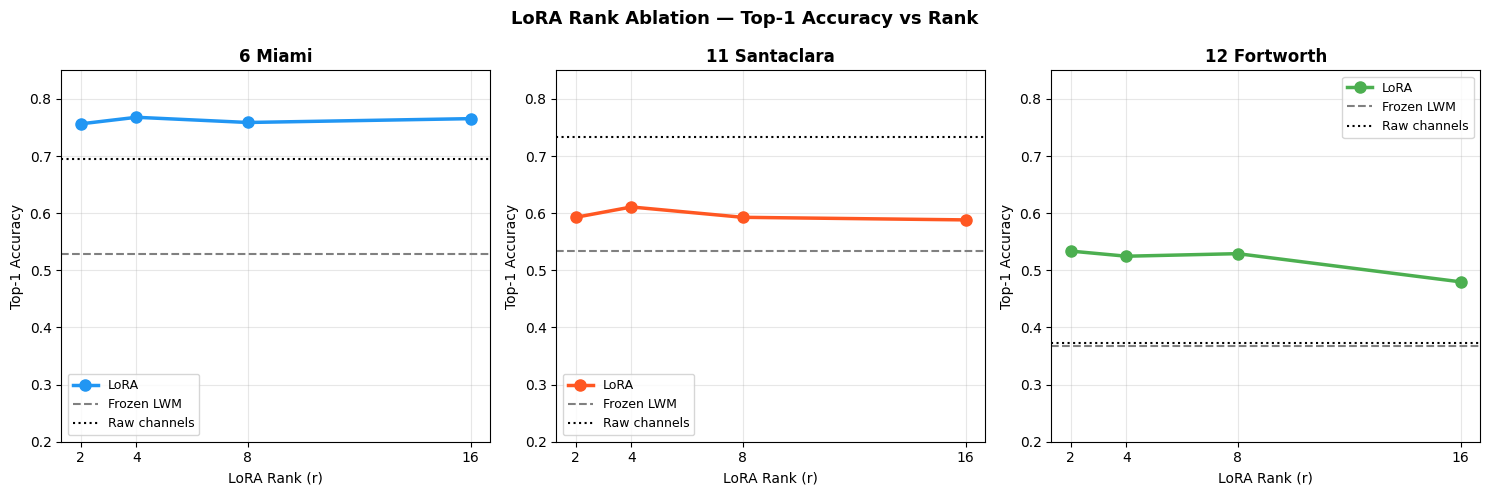

Ablation results logged to W&B.


In [10]:
# log ablation table to W&B
rows = []
for sc in SCENARIOS:
    for r in LORA_RANKS:
        rows.append([sc, r, round(ablation_results[sc][r], 4)])

ablation_table = wandb.Table(
    columns=["scenario", "lora_rank", "val_top1"],
    data=rows
)
wandb.log({"lora/rank_ablation_table": ablation_table})

# plot rank ablation curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("LoRA Rank Ablation — Top-1 Accuracy vs Rank",
             fontsize=13, fontweight="bold")

# reference lines from Notebook 02
frozen_ref = {"city_6_miami": 0.528, "city_11_santaclara": 0.534,
              "city_12_fortworth": 0.368}
raw_ref    = {"city_6_miami": 0.694, "city_11_santaclara": 0.733,
              "city_12_fortworth": 0.372}
colors     = ["#2196F3", "#FF5722", "#4CAF50"]

for i, sc_name in enumerate(SCENARIOS):
    ax   = axes[i]
    vals = [ablation_results[sc_name][r] for r in LORA_RANKS]
    ax.plot(LORA_RANKS, vals, "o-", color=colors[i],
            linewidth=2.5, markersize=8, label="LoRA")
    ax.axhline(frozen_ref[sc_name], color="gray",
               linestyle="--", linewidth=1.5, label=f"Frozen LWM")
    ax.axhline(raw_ref[sc_name], color="black",
               linestyle=":", linewidth=1.5, label=f"Raw channels")
    ax.set_title(sc_name.replace("city_", "").replace("_", " ").title(),
                 fontweight="bold")
    ax.set_xlabel("LoRA Rank (r)")
    ax.set_ylabel("Top-1 Accuracy")
    ax.set_xticks(LORA_RANKS)
    ax.set_ylim(0.2, 0.85)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = FIG_DIR / "03_lora_rank_ablation.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
wandb.log({"lora/rank_ablation_chart": wandb.Image(str(fig_path))})
print("Ablation results logged to W&B.")

## Section 9 — Cross-Scenario Transfer with LoRA

The core LoRA domain adaptation experiment:
1. Train a full LWMLoRA model on Miami (source — largest dataset, 10,441 samples)
2. Transfer to Santaclara and Fortworth using only 20% of target data
3. Compare three transfer strategies:
   - **No adaptation**: Miami-trained model evaluated directly on target (zero-shot)
   - **Full fine-tune**: All parameters updated on 20% target data
   - **LoRA-only**: Only LoRA adapters updated on 20% target data (encoder frozen)

This tests whether LoRA enables cheap per-scenario adaptation.

In [11]:
TRANSFER_EPOCHS    = 30
TRANSFER_LR        = 5e-4    # lower LR for adaptation
TARGET_TRAIN_RATIO = 0.2     # only 20% of target data for adaptation
BEST_R             = 4       # best rank from ablation

transfer_results = {}

# step 1: train source model on Miami
print("Step 1: Training source model on city_6_miami (r=4)...")
src_patches = scenario_data["city_6_miami"]["patches"]
src_labels  = scenario_data["city_6_miami"]["labels"]
src_train, src_val = make_loaders(src_patches, src_labels,
                                  train_ratio=0.8, batch_size=BATCH, seed=SEED)

source_model = build_lwm_lora(r=BEST_R, device=device)
best_src, _  = train_lora(
    source_model, src_train, src_val,
    epochs=TRANSFER_EPOCHS, lr=LR, device=device,
    wandb_prefix="transfer/source_miami"
)
print(f"Source model top-1 on Miami (val): {best_src:.3f}")

# save source model weights for reloading
src_ckpt = CKPT_DIR / "lwm_lora_r4_source_miami.pt"
torch.save(source_model.state_dict(), str(src_ckpt))

# step 2: transfer to each target scenario
TARGET_SCENARIOS = ["city_11_santaclara", "city_12_fortworth"]

for tgt_name in TARGET_SCENARIOS:
    print(f"\n{'='*55}")
    print(f"Target: {tgt_name} (20% train data)")
    print(f"{'='*55}")
    transfer_results[tgt_name] = {}

    tgt_patches = scenario_data[tgt_name]["patches"]
    tgt_labels  = scenario_data[tgt_name]["labels"]

    # use 20% for adaptation, 80% for evaluation
    tgt_train, tgt_val = make_loaders(
        tgt_patches, tgt_labels,
        train_ratio=TARGET_TRAIN_RATIO,
        batch_size=BATCH, seed=SEED
    )

    # --- A: zero-shot (no adaptation) ---
    print("\n[A] Zero-shot: Miami model → Target (no adaptation)")
    source_model.eval()
    correct_top1 = correct_top3 = total = 0
    with torch.no_grad():
        for X_batch, y_batch in tgt_val:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = source_model(X_batch)
            top3   = torch.topk(logits, k=3, dim=1).indices
            correct_top1 += (top3[:, 0] == y_batch).sum().item()
            correct_top3 += (top3 == y_batch.unsqueeze(1)).any(dim=1).sum().item()
            total        += len(y_batch)
    zero_shot_top1 = correct_top1 / total
    zero_shot_top3 = correct_top3 / total
    transfer_results[tgt_name]["zero_shot"] = zero_shot_top1
    print(f"  Zero-shot top-1: {zero_shot_top1:.3f}, top-3: {zero_shot_top3:.3f}")

    # --- B: LoRA-only adaptation ---
    print("\n[B] LoRA-only adaptation (20% target data)")
    lora_adapt_model = build_lwm_lora(r=BEST_R, device=device)
    lora_adapt_model.load_state_dict(torch.load(str(src_ckpt), map_location=device))

    # freeze everything except LoRA adapters + MLP head
    for name, p in lora_adapt_model.named_parameters():
        if "lora_A" in name or "lora_B" in name or "head" in name:
            p.requires_grad = True
        else:
            p.requires_grad = False

    best_lora_adapt, _ = train_lora(
        lora_adapt_model, tgt_train, tgt_val,
        epochs=TRANSFER_EPOCHS, lr=TRANSFER_LR, device=device,
        wandb_prefix=f"transfer/lora_adapt_{tgt_name}"
    )
    transfer_results[tgt_name]["lora_adapt"] = best_lora_adapt
    print(f"  LoRA adapt top-1: {best_lora_adapt:.3f}")

    # --- C: full fine-tune adaptation ---
    print("\n[C] Full fine-tune adaptation (20% target data)")
    full_ft_model = build_lwm_lora(r=BEST_R, device=device)
    full_ft_model.load_state_dict(torch.load(str(src_ckpt), map_location=device))

    # unfreeze everything
    for p in full_ft_model.parameters():
        p.requires_grad = True

    best_full_ft, _ = train_lora(
        full_ft_model, tgt_train, tgt_val,
        epochs=TRANSFER_EPOCHS, lr=TRANSFER_LR, device=device,
        wandb_prefix=f"transfer/full_ft_{tgt_name}"
    )
    transfer_results[tgt_name]["full_ft"] = best_full_ft
    print(f"  Full fine-tune top-1: {best_full_ft:.3f}")

    del lora_adapt_model, full_ft_model
    torch.cuda.empty_cache()

print(f"\n{'='*55}")
print("CROSS-SCENARIO TRANSFER RESULTS")
print(f"{'='*55}")
print(f"{'Target':<25} {'Zero-shot':>10} {'LoRA adapt':>12} {'Full FT':>10}")
print("-" * 60)
for tgt, r in transfer_results.items():
    print(f"{tgt:<25} {r['zero_shot']:>10.3f} {r['lora_adapt']:>12.3f} "
          f"{r['full_ft']:>10.3f}")

Step 1: Training source model on city_6_miami (r=4)...
  Epoch  10/30 | loss=1.0565 | top1=0.640 | top3=0.949
  Epoch  20/30 | loss=0.8245 | top1=0.736 | top3=0.964
  Epoch  30/30 | loss=0.7343 | top1=0.755 | top3=0.967
Source model top-1 on Miami (val): 0.755

Target: city_11_santaclara (20% train data)

[A] Zero-shot: Miami model → Target (no adaptation)
  Zero-shot top-1: 0.310, top-3: 0.699

[B] LoRA-only adaptation (20% target data)
  Epoch  10/30 | loss=1.6746 | top1=0.566 | top3=0.883
  Epoch  20/30 | loss=1.2243 | top1=0.644 | top3=0.921
  Epoch  30/30 | loss=1.2192 | top1=0.655 | top3=0.924
  LoRA adapt top-1: 0.656

[C] Full fine-tune adaptation (20% target data)
  Epoch  10/30 | loss=1.4040 | top1=0.592 | top3=0.897
  Epoch  20/30 | loss=0.9933 | top1=0.615 | top3=0.914
  Epoch  30/30 | loss=1.0067 | top1=0.649 | top3=0.915
  Full fine-tune top-1: 0.653

Target: city_12_fortworth (20% train data)

[A] Zero-shot: Miami model → Target (no adaptation)
  Zero-shot top-1: 0.329, 

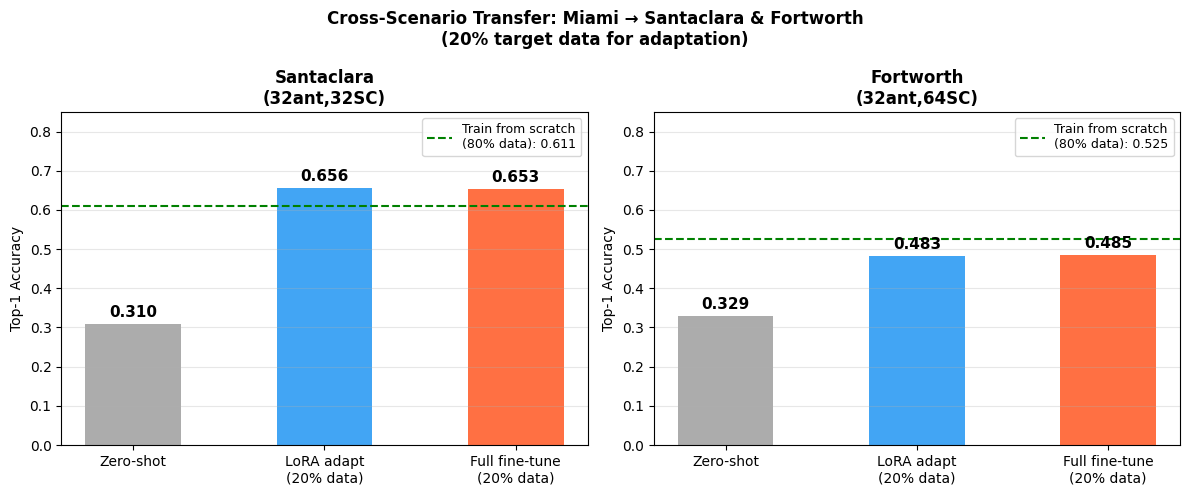

KEY FINDINGS

LoRA rank ablation (r=4 optimal):
  city_6_miami: 0.768 top-1
  city_11_santaclara: 0.611 top-1
  city_12_fortworth: 0.525 top-1

Cross-scenario transfer (Miami → target, 20% data):
  city_11_santaclara:
    Zero-shot:   0.310
    LoRA adapt:  0.656  (+0.003 vs full FT)
    Full FT:     0.653
  city_12_fortworth:
    Zero-shot:   0.329
    LoRA adapt:  0.483  (-0.002 vs full FT)
    Full FT:     0.485


city_11_santaclara/lora_r16/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
city_11_santaclara/lora_r16/train_loss,█▇▆▅▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
city_11_santaclara/lora_r16/val_top1,▁▂▃▃▄▄▅▅▆▆▇▇▇▇█▇▇▇▇▇██████████
city_11_santaclara/lora_r16/val_top3,▁▃▄▃▄▆▆▇▇▇▇▇▇▇▇███████████████
city_11_santaclara/lora_r2/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
city_11_santaclara/lora_r2/train_loss,█▇▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
city_11_santaclara/lora_r2/val_top1,▁▃▃▃▃▅▆▆▆▆▇▇▇▇▇███████████████
city_11_santaclara/lora_r2/val_top3,▁▃▄▄▅▆▆▇▇▇▇███████████████████
city_11_santaclara/lora_r4/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
city_11_santaclara/lora_r4/train_loss,█▇▅▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+58,...



W&B run closed.


In [12]:
# log transfer results to W&B
transfer_rows = []
for tgt, r in transfer_results.items():
    transfer_rows.append([tgt, round(r["zero_shot"], 4),
                          round(r["lora_adapt"], 4),
                          round(r["full_ft"], 4),
                          round(r["lora_adapt"] - r["zero_shot"], 4),
                          round(r["lora_adapt"] - r["full_ft"], 4)])

transfer_table = wandb.Table(
    columns=["target", "zero_shot", "lora_adapt", "full_ft",
             "gain_over_zeroshot", "lora_vs_fullft"],
    data=transfer_rows
)
wandb.log({"transfer/results_table": transfer_table})

# plot transfer comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Cross-Scenario Transfer: Miami → Santaclara & Fortworth\n"
             "(20% target data for adaptation)",
             fontsize=12, fontweight="bold")

bar_labels  = ["Zero-shot", "LoRA adapt\n(20% data)", "Full fine-tune\n(20% data)"]
bar_colors  = ["#9E9E9E", "#2196F3", "#FF5722"]
tgt_display = ["Santaclara\n(32ant,32SC)", "Fortworth\n(32ant,64SC)"]

for i, (tgt_name, tgt_label) in enumerate(
        zip(TARGET_SCENARIOS, tgt_display)):
    ax   = axes[i]
    vals = [
        transfer_results[tgt_name]["zero_shot"],
        transfer_results[tgt_name]["lora_adapt"],
        transfer_results[tgt_name]["full_ft"],
    ]
    bars = ax.bar(bar_labels, vals, color=bar_colors, alpha=0.85, width=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold")

    # reference: train from scratch on 20% target data (from ablation)
    scratch_ref = ablation_results[tgt_name][BEST_R]
    ax.axhline(scratch_ref, color="green", linestyle="--",
               linewidth=1.5, label=f"Train from scratch\n(80% data): {scratch_ref:.3f}")
    ax.set_title(tgt_label, fontweight="bold")
    ax.set_ylabel("Top-1 Accuracy")
    ax.set_ylim(0, 0.85)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig_path = FIG_DIR / "03_transfer_results.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
wandb.log({"transfer/comparison_chart": wandb.Image(str(fig_path))})

# final summary
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print(f"\nLoRA rank ablation (r=4 optimal):")
for sc in SCENARIOS:
    print(f"  {sc}: {ablation_results[sc][4]:.3f} top-1")

print(f"\nCross-scenario transfer (Miami → target, 20% data):")
for tgt, r in transfer_results.items():
    delta = r["lora_adapt"] - r["full_ft"]
    print(f"  {tgt}:")
    print(f"    Zero-shot:   {r['zero_shot']:.3f}")
    print(f"    LoRA adapt:  {r['lora_adapt']:.3f}  "
          f"({'+'if delta>=0 else ''}{delta:.3f} vs full FT)")
    print(f"    Full FT:     {r['full_ft']:.3f}")

wandb.finish()
print("\nW&B run closed.")